In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import cv2 

In [37]:
import os
import cv2
import numpy as np

In [38]:
IMG_SIZE = 224

In [39]:
X = []
y = []

In [40]:
path_open = "C:/eye open train/"

open_images = os.listdir(path_open)

for img_name in open_images:
    img_path = os.path.join(path_open, img_name)

    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        y.append(1)      # Open eye

In [41]:
path_closed = "C:/eye close train/"

closed_images = os.listdir(path_closed)

for img_name in closed_images:
    img_path = os.path.join(path_closed, img_name)

    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        y.append(0)      # Closed eye

In [42]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

In [43]:
X = X / 255.0

In [44]:
print(X.shape)
print(y.shape)

(6000, 224, 224, 3)
(6000,)


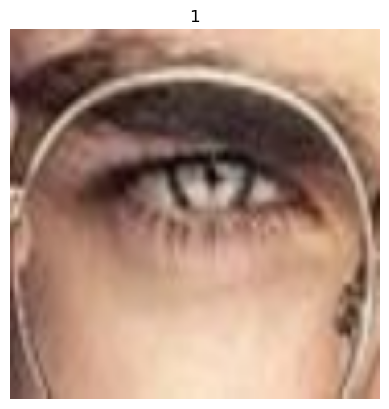

In [45]:
import matplotlib.pyplot as plt

plt.imshow(X[0])
plt.title(y[0])
plt.axis("off")
plt.show()

In [46]:
pd.DataFrame(y).value_counts()

0
0    3000
1    3000
Name: count, dtype: int64

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [49]:
X_train.shape

(4800, 224, 224, 3)

In [50]:
y_train.shape

(4800,)

In [51]:
from tensorflow.keras.models import Sequential

In [52]:
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization

In [53]:
cnn_model=Sequential()

In [54]:
cnn_model.add(Input(shape=(224,224,3)))

In [55]:
cnn_model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))


In [56]:
cnn_model.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

In [57]:
cnn_model.add(Conv2D(64,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))


In [58]:
cnn_model.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

In [59]:
cnn_model.add(Conv2D(128,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))


In [60]:
cnn_model.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

In [61]:
cnn_model.add(Flatten())

In [62]:
cnn_model.add(Dense(128,activation="relu"))

In [63]:
cnn_model.add(Dense(64,activation="relu"))

In [64]:
cnn_model.add(Dense(2,activation="sigmoid"))

In [65]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,177,346 (42.64 MB)

 Trainable params: 11,177,346 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
cnn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [67]:
cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7892 - loss: 0.4425 - val_accuracy: 0.9008 - val_loss: 0.2551
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9015 - loss: 0.2520 - val_accuracy: 0.9167 - val_loss: 0.2277
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9287 - loss: 0.1874 - val_accuracy: 0.9275 - val_loss: 0.1926
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9381 - loss: 0.1522 - val_accuracy: 0.9217 - val_loss: 0.1926
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9548 - loss: 0.1145 - val_accuracy: 0.9267 - val_loss: 0.1859
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9717 - loss: 0.0746 - val_accuracy: 0.9192 - val_loss: 0.2737
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.9783 - loss: 0.0601 - val_accuracy: 0.9383 - val_loss: 0.2181
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9810 - loss: 0.0468 - val_accu

In [79]:
cnn_model.evaluate(X_test, y_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.9375 - loss: 0.3060


[0.30598461627960205, 0.9375]

In [80]:
p1=X_train[4444].reshape((1,) + X_train[4444].shape)

In [81]:
cnn_model.predict(p1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


array([[0.99686635, 0.01956246]], dtype=float32)

In [82]:
np.argmax(cnn_model.predict(p1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


np.int64(0)

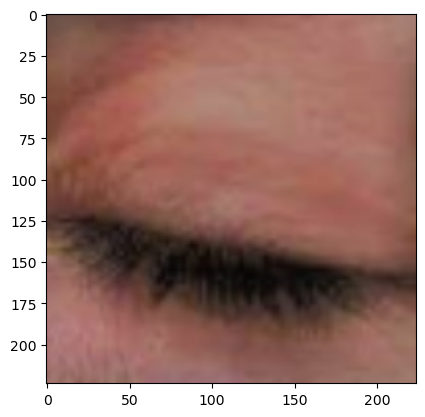

In [83]:
plt.imshow(X_train[4444])

In [84]:
p2=X_test[1090].reshape((1,) + X_test[1090].shape)

In [85]:
cnn_model.predict(p2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


array([[0.0850435 , 0.99046385]], dtype=float32)

In [86]:
np.argmax(cnn_model.predict(p2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


np.int64(1)

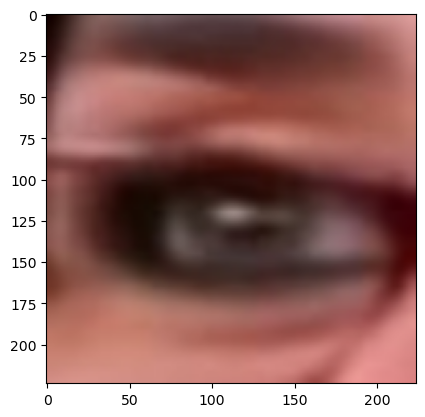

In [87]:
plt.imshow(X_test[1090])

In [88]:
cnn_model.save("eye_movement_model.keras")